# LIBERO Goal checkpoint-600: command and closed-loop state analysis

This notebook audits the suite-specific model trained from `checkpoint-1600`. It deliberately separates **teacher-forced sampled-command quality** from **closed-loop physical behavior**. The closed-loop section starts from one exact demonstrated MuJoCo state, re-infers every 1 or 4 actions, and compares:

1. recorded LIBERO command versus executed RDT command;
2. demonstrated state after the recorded command versus state realized after the RDT command;
3. motion, rotation, fingers, gripper phases, transition timing, cameras, and videos.

After the policy leaves the demonstrated trajectory, same-timestep errors measure accumulated closed-loop divergence as well as direct prediction error.

In [1]:
# 0 — imports and repository discovery
import gc
import json
import os
import subprocess
import sys
from dataclasses import replace
from pathlib import Path

os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/thinkflow-cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/thinkflow-matplotlib')

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Video, display

def find_repo_root(start):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src/thinkflow_rdt').is_dir() and (candidate / 'scripts').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate ThinkFlow-RDT-1B')

REPO_ROOT = find_repo_root(Path.cwd())
for path in (REPO_ROOT, REPO_ROOT / 'src', REPO_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
print('Repository:', REPO_ROOT)
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'unavailable')

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Repository: /home/ubuntu/ThinkFlow-RDT-1B
CUDA: True NVIDIA RTX 6000 Ada Generation


## 1. Configuration

The defaults point at the stopped suite-specific run. Change only this cell when comparing a later checkpoint. `RUN_EXACT_DEMO_ROLLOUTS=True` performs two real simulator jobs and can take several minutes.

In [2]:
# 1 — edit paths/settings here
CHECKPOINT_FOLDER = REPO_ROOT / 'outputs/libero_goal_from_checkpoint1600/checkpoint-600'
BASE_ARTIFACT = REPO_ROOT / 'outputs/checkpoint1600_merged_base_for_libero'
CONFIG_PATH = REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'
SUITE = 'libero_goal'
CACHE_ROOT = REPO_ROOT / 'cache_features_libero_b0_raw_ortho6d' / SUITE
DEMO_DATASET_ROOT = REPO_ROOT / 'libero-dataset'
LIBERO_ROOT = Path('/home/ubuntu/LIBERO')
SIGLIP_MODEL_ID = Path('/home/ubuntu/models/siglip-so400m-patch14-384')
SIGLIP_FALLBACK_MODEL_ID = 'google/siglip-so400m-patch14-384'

VALIDATION_SAMPLES = 64
VALIDATION_BATCH_SIZE = 16
DIFFUSION_REPEATS = 1
INFERENCE_STEPS = 5
SEED = 42

RUN_EXACT_DEMO_ROLLOUTS = True
DEMO_RANDOM_SEED = 20260812
ACTION_CHUNKS = (1, 4)
MAX_STEPS = 300
VIDEO_RESOLUTION = 512

checkpoint_tag = f'{CHECKPOINT_FOLDER.parent.name}__{CHECKPOINT_FOLDER.name}'
ANALYSIS_ROOT = REPO_ROOT / 'outputs/libero_goal_checkpoint_analysis' / checkpoint_tag
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
print('Checkpoint:', CHECKPOINT_FOLDER)
print('Base:', BASE_ARTIFACT)
print('Suite cache:', CACHE_ROOT)
print('Analysis output:', ANALYSIS_ROOT)

Checkpoint: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_from_checkpoint1600/checkpoint-600
Base: /home/ubuntu/ThinkFlow-RDT-1B/outputs/checkpoint1600_merged_base_for_libero
Suite cache: /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d/libero_goal
Analysis output: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_checkpoint_analysis/libero_goal_from_checkpoint1600__checkpoint-600


## 2. Artifact and cache audit

In [3]:
# 2 — fail early on a wrong checkpoint/base/cache combination
required = {
    'checkpoint metadata': CHECKPOINT_FOLDER / 'metadata.json',
    'checkpoint interfaces': CHECKPOINT_FOLDER / 'interfaces.pt',
    'checkpoint LoRA': CHECKPOINT_FOLDER / 'rdt_lora/adapter_model.safetensors',
    'merged checkpoint-1600 base': BASE_ARTIFACT / 'rdt_full.pt',
    'config': CONFIG_PATH,
    'train manifest': CACHE_ROOT / 'train/manifest.jsonl',
    'validation manifest': CACHE_ROOT / 'validation/manifest.jsonl',
    'LIBERO': LIBERO_ROOT,
    'demo root': DEMO_DATASET_ROOT / SUITE,
}
missing = {name: str(path) for name, path in required.items() if not path.exists()}
if missing:
    raise FileNotFoundError(missing)
metadata = json.loads((CHECKPOINT_FOLDER / 'metadata.json').read_text())
base_metadata_path = BASE_ARTIFACT / 'metadata.json'
base_metadata = json.loads(base_metadata_path.read_text()) if base_metadata_path.exists() else {}
audit = {
    'checkpoint_step': metadata.get('global_step'),
    'effective_global_batch': metadata.get('effective_global_batch'),
    'mask_noisy_gripper_input': metadata.get('mask_noisy_gripper_input'),
    'training_objective': metadata.get('training_objective'),
    'merged_base_source': base_metadata.get('merged_from'),
    'suite': SUITE,
}
display(audit)
(ANALYSIS_ROOT / 'artifact_audit.json').write_text(json.dumps(audit, indent=2, default=str) + '\n')

{'checkpoint_step': 600,
 'effective_global_batch': 256,
 'mask_noisy_gripper_input': True,
 'training_objective': {'horizon_loss_weights': [5.0,
   5.0,
   5.0,
   5.0,
   3.0,
   3.0,
   3.0,
   3.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0],
  'mask_noisy_gripper_input': True,
  'gripper_bce_weight': 1.0,
  'gripper_bce_logit_scale': 5.0,
  'rotation_geodesic_weight': 0.0},
 'merged_base_source': '/home/ubuntu/ThinkFlow-RDT-1B/checkpoint-1600',
 'suite': 'libero_goal'}

1109

## 3. Teacher-forced real diffusion sampling

These samples use recorded validation images, state, Qwen KV, and T5 features. No environment error can accumulate here. This establishes whether checkpoint-600 learned the suite cache before testing control.

In [4]:
# 3 — encode a fixed, reproducible validation audit set
from scripts.overfit_libero_cached import build_online_siglip_collator, encode_fixed_feature_batches, evaluate_real_sampling
from thinkflow_rdt.adapters.libero import rdt_action_to_libero
from thinkflow_rdt.config import load_config
from thinkflow_rdt.data import ONLINE_SIGLIP_REQUIRED_KEYS, CachedFeatureDataset
from thinkflow_rdt.train import infer_gripper_release_mask, load_online_siglip

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for RDT-1B sampling')
device = torch.device('cuda')
cfg = load_config(CONFIG_PATH)
cfg = replace(cfg, noise_scheduler=replace(cfg.noise_scheduler, num_inference_timesteps=INFERENCE_STEPS))
saved_model_cfg = metadata.get('config', {}).get('model', {})
structural_keys = ('state_dim', 'action_dim', 'pred_horizon', 'qwen_fusion', 'state_encoder_layout', 'action_encoder_layout')
mismatches = {k: (saved_model_cfg[k], getattr(cfg.model, k)) for k in structural_keys if k in saved_model_cfg and saved_model_cfg[k] != getattr(cfg.model, k)}
if mismatches:
    raise ValueError(f'Checkpoint/config mismatch: {mismatches}')

manifest = CACHE_ROOT / 'validation/manifest.jsonl'
dataset = CachedFeatureDataset(manifest, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS)
count = min(VALIDATION_SAMPLES, len(dataset))
indices = np.unique(np.linspace(0, len(dataset) - 1, count, dtype=int)).tolist()
samples = [dataset[i] for i in indices]
siglip_id = str(SIGLIP_MODEL_ID) if SIGLIP_MODEL_ID.exists() else SIGLIP_FALLBACK_MODEL_ID
processor, siglip = load_online_siglip(model_id=siglip_id, fallback_model_id=SIGLIP_FALLBACK_MODEL_ID, cfg=cfg, device=device)
validation_batches = encode_fixed_feature_batches(
    samples, cfg=cfg, batch_size=VALIDATION_BATCH_SIZE, device=device,
    collator=build_online_siglip_collator(cfg), processor=processor, encoder=siglip,
)
for batch in validation_batches:
    raw_target = torch.from_numpy(rdt_action_to_libero(batch['actions'].float().numpy()))
    batch['gripper_release_mask'] = infer_gripper_release_mask(raw_target[..., 6], batch['action_time_mask'].bool())
print('Validation dataset:', len(dataset), 'selected:', len(indices), 'batches:', len(validation_batches))
del siglip, processor
gc.collect(); torch.cuda.empty_cache()

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 448/448 [00:01<00:00, 317.35it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder

Validation dataset: 7690 selected: 64 batches: 4


In [5]:
# 3.1 — load step 600 and perform real five-step diffusion sampling
from thinkflow_rdt.checkpoint import load_trainable_artifact
from thinkflow_rdt.model import SFTConditionedRDT

model = SFTConditionedRDT(cfg, load_pretrained=True, base_artifact=str(BASE_ARTIFACT))
load_trainable_artifact(model, CHECKPOINT_FOLDER, trainable=False)
model.to(device).eval()
metrics, tensors = evaluate_real_sampling(
    model, validation_batches, device=device, repeats=DIFFUSION_REPEATS, seed=SEED + 1_000_000
)
metrics_path = ANALYSIS_ROOT / 'teacher_forced_metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2, default=str) + '\n')
torch.save(tensors, ANALYSIS_ROOT / 'teacher_forced_tensors.pt')
print('Loaded step:', metadata.get('global_step'))
print('Base load report:', model.base_artifact_report)
display(metrics)

Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Loaded step: 600
Base load report: {'loaded_tensors': 602, 'reinitialized_tensors': ['final_layer.ffn_final.fc2.bias', 'final_layer.ffn_final.fc2.weight'], 'adapted_tensors': ['lang_cond_pos_embed'], 'shape_mismatches': {'lang_cond_pos_embed': ((1, 129, 2048), (1, 128, 2048)), 'final_layer.ffn_final.fc2.weight': ((7, 2048), (10, 2048)), 'final_layer.ffn_final.fc2.bias': ((7,), (10,))}}


{'horizon_rmse': {'1': {'command_rmse_7d': 0.3169022798538208,
   'motion_rmse_6d': 0.26729723811149597,
   'gripper_rmse': 0.5237389206886292,
   'valid_commands': 64},
  '4': {'command_rmse_7d': 0.3182322084903717,
   'motion_rmse_6d': 0.2655603885650635,
   'gripper_rmse': 0.534572958946228,
   'valid_commands': 252},
  '8': {'command_rmse_7d': 0.32671239972114563,
   'motion_rmse_6d': 0.2613734006881714,
   'gripper_rmse': 0.5807673335075378,
   'valid_commands': 498},
  '64': {'command_rmse_7d': 0.37351173162460327,
   'motion_rmse_6d': 0.29849910736083984,
   'gripper_rmse': 0.6648058891296387,
   'valid_commands': 3283}},
 'per_dimension_correlation': {'dx': 0.5119623972604722,
  'dy': 0.46213442444217634,
  'dz': 0.5177943268856412,
  'dRx': 0.48746175968812927,
  'dRy': 0.4609883621260125,
  'dRz': 0.5773505408627668,
  'gripper': 0.7495077599144176},
 'per_dimension_sign_agreement': {'dx': 0.5641181845872677,
  'dy': 0.5089856838257691,
  'dz': 0.6886993603411514,
  'dRx': 0.

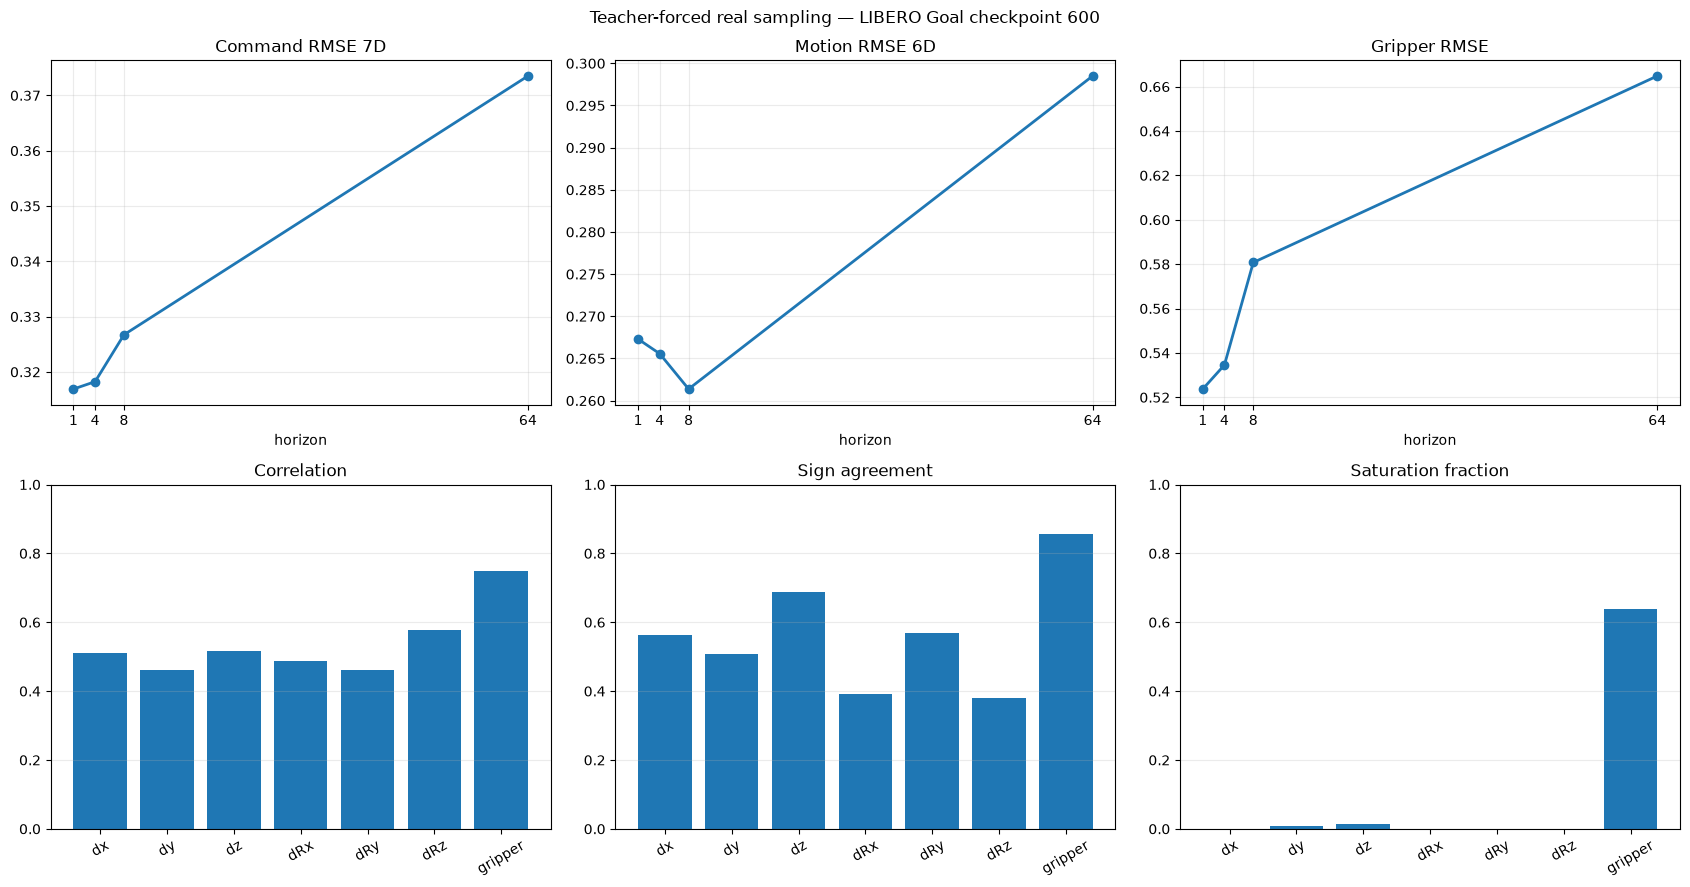

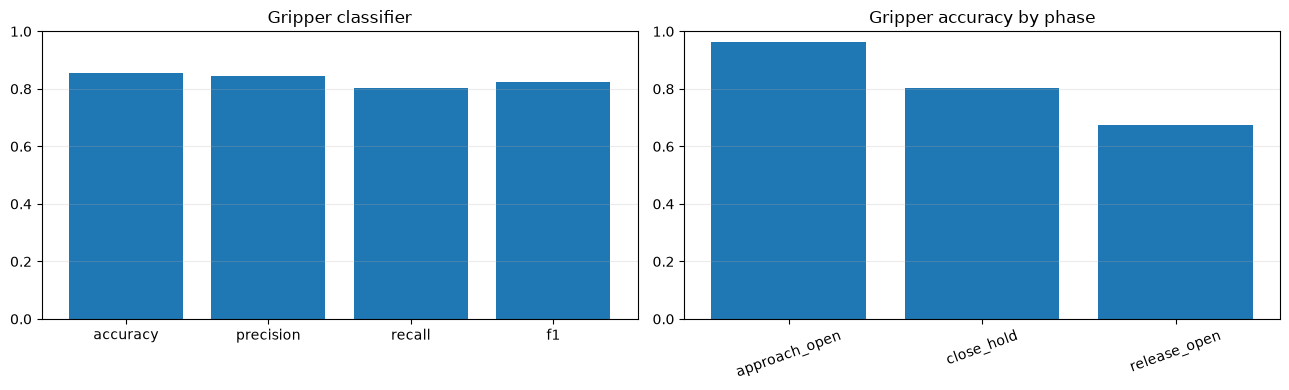

,horizon,command_rmse_7d,motion_rmse_6d,gripper_rmse,valid_commands
0,1,0.316902,0.267297,0.523739,64
1,4,0.318232,0.265560,0.534573,252
2,8,0.326712,0.261373,0.580767,498
3,64,0.373512,0.298499,0.664806,3283


,dimension,correlation,sign_agreement,saturation
0,dx,0.511962,0.564118,0.000000
1,dy,0.462134,0.508986,0.007920
2,dz,0.517794,0.688699,0.014925
3,dRx,0.487462,0.390801,0.000000
4,dRy,0.460988,0.569601,0.000000
5,dRz,0.577351,0.378922,0.000000
6,gripper,0.749508,0.856838,0.638440


,phase,accuracy,commands
0,approach_open,0.961957,1472
1,close_hold,0.803965,1362
2,release_open,0.672606,449


{'opportunities': 22,
 'detected': 12,
 'missed': 10,
 'mean_signed_error_steps': 5.583333333333333,
 'mae_steps': 7.916666666666667}

In [6]:
# 3.2 — horizon, per-dimension, and gripper-phase plots
horizon_rows = [{'horizon': int(h), **v} for h, v in metrics['horizon_rmse'].items() if v is not None]
horizon_df = pd.DataFrame(horizon_rows).sort_values('horizon')
dimensions = list(metrics['per_dimension_correlation'])
phase = metrics.get('gripper_phase', {})

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, key, title in zip(axes[0], ('command_rmse_7d', 'motion_rmse_6d', 'gripper_rmse'), ('Command RMSE 7D', 'Motion RMSE 6D', 'Gripper RMSE')):
    ax.plot(horizon_df.horizon, horizon_df[key], marker='o', linewidth=2)
    ax.set_xticks([1, 4, 8, 64]); ax.set_title(title); ax.set_xlabel('horizon'); ax.grid(alpha=.25)
for ax, values, title in zip(axes[1], (metrics['per_dimension_correlation'], metrics['per_dimension_sign_agreement'], metrics['per_dimension_saturation_fraction']), ('Correlation', 'Sign agreement', 'Saturation fraction')):
    ax.bar(dimensions, [values[d] for d in dimensions]); ax.set_ylim(0, 1); ax.set_title(title); ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=.25)
fig.suptitle('Teacher-forced real sampling — LIBERO Goal checkpoint 600')
plt.tight_layout(); plt.savefig(ANALYSIS_ROOT / 'teacher_forced_quality.png', dpi=160, bbox_inches='tight'); plt.show()

phase_names = [p for p in ('approach_open', 'close_hold', 'release_open') if p in phase]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(['accuracy', 'precision', 'recall', 'f1'], [metrics['gripper'][k] for k in ('accuracy', 'precision', 'recall', 'f1')]); axes[0].set_ylim(0, 1); axes[0].set_title('Gripper classifier'); axes[0].grid(axis='y', alpha=.25)
axes[1].bar(phase_names, [phase[p]['accuracy'] for p in phase_names]); axes[1].set_ylim(0, 1); axes[1].set_title('Gripper accuracy by phase'); axes[1].tick_params(axis='x', rotation=20); axes[1].grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()
display(horizon_df)
display(pd.DataFrame([{'dimension': d, 'correlation': metrics['per_dimension_correlation'][d], 'sign_agreement': metrics['per_dimension_sign_agreement'][d], 'saturation': metrics['per_dimension_saturation_fraction'][d]} for d in dimensions]))
display(pd.DataFrame([{'phase': p, **phase[p]} for p in phase_names]))
display(phase.get('release_transition_timing', {}))

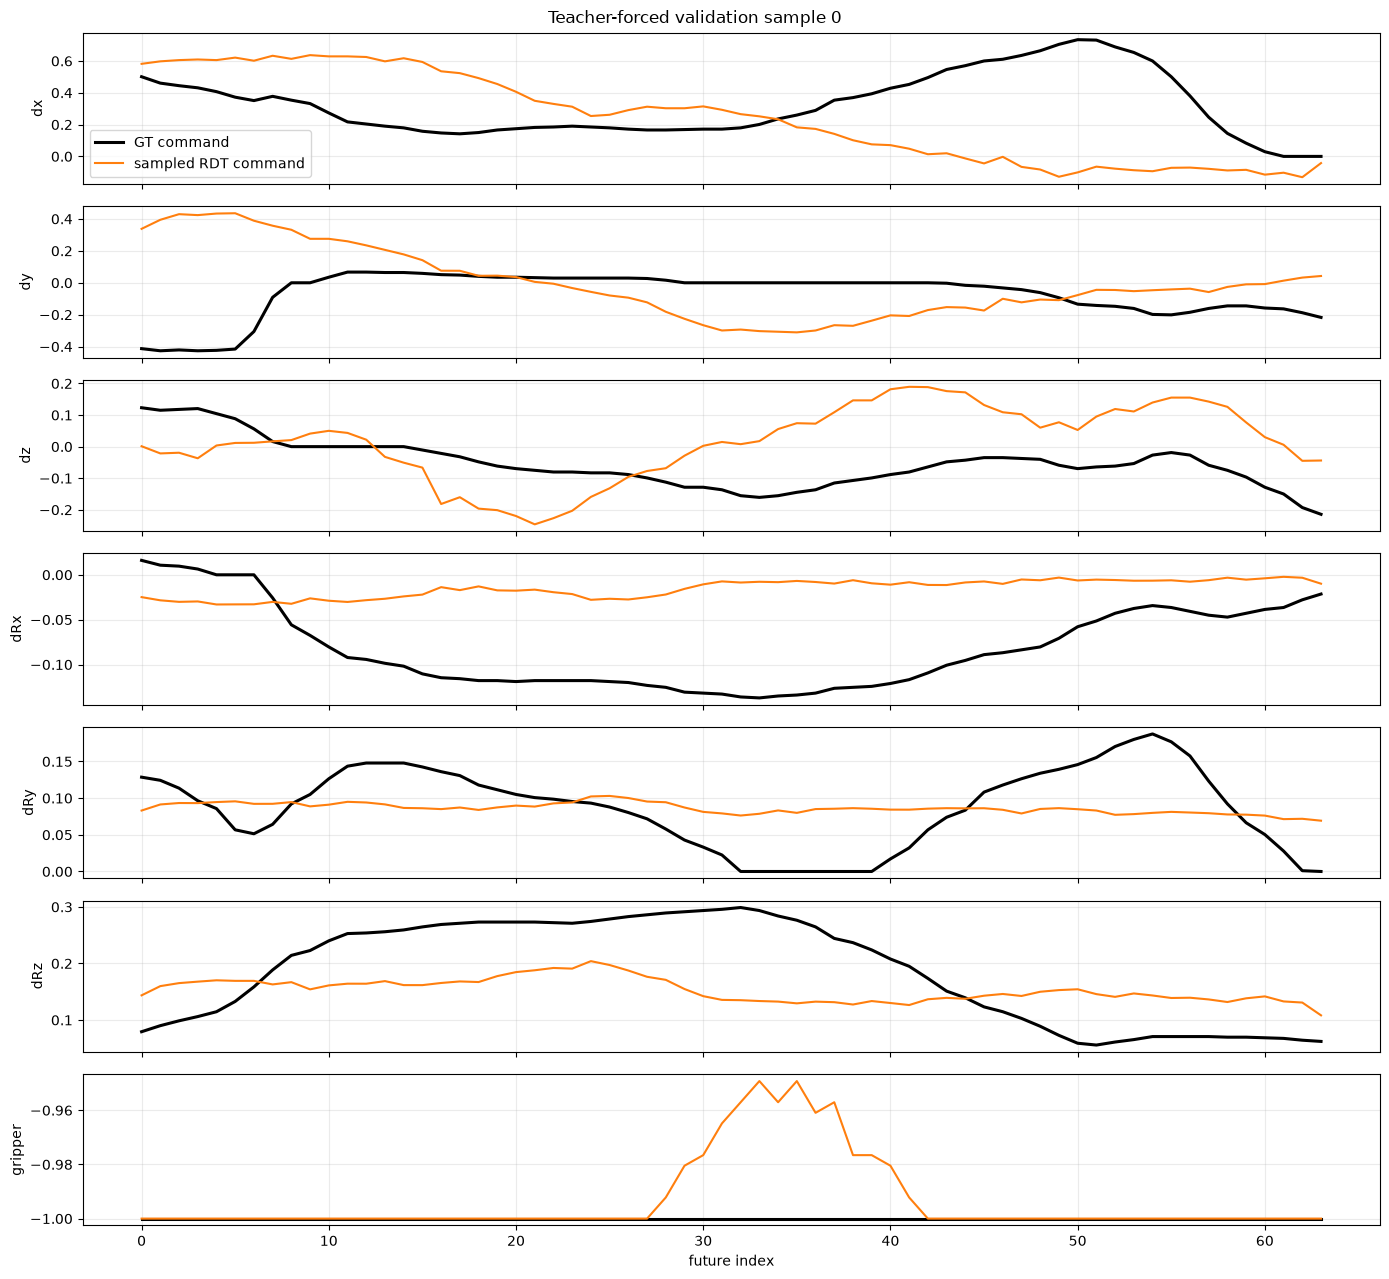

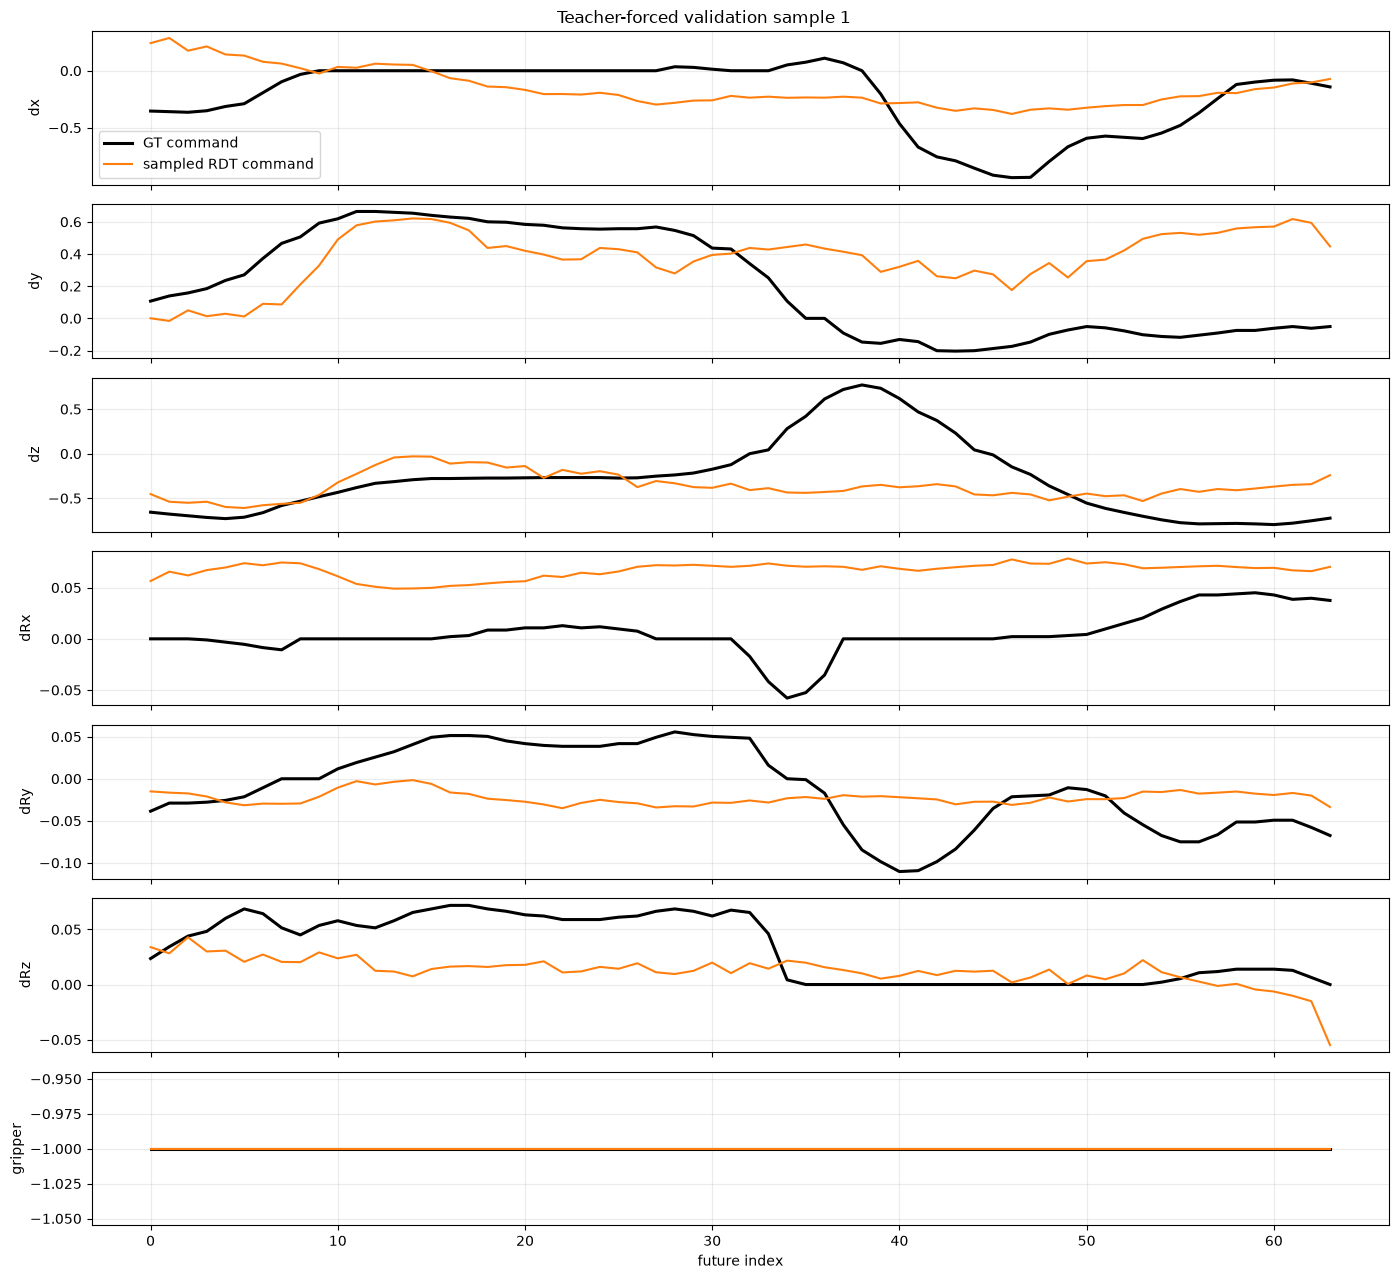

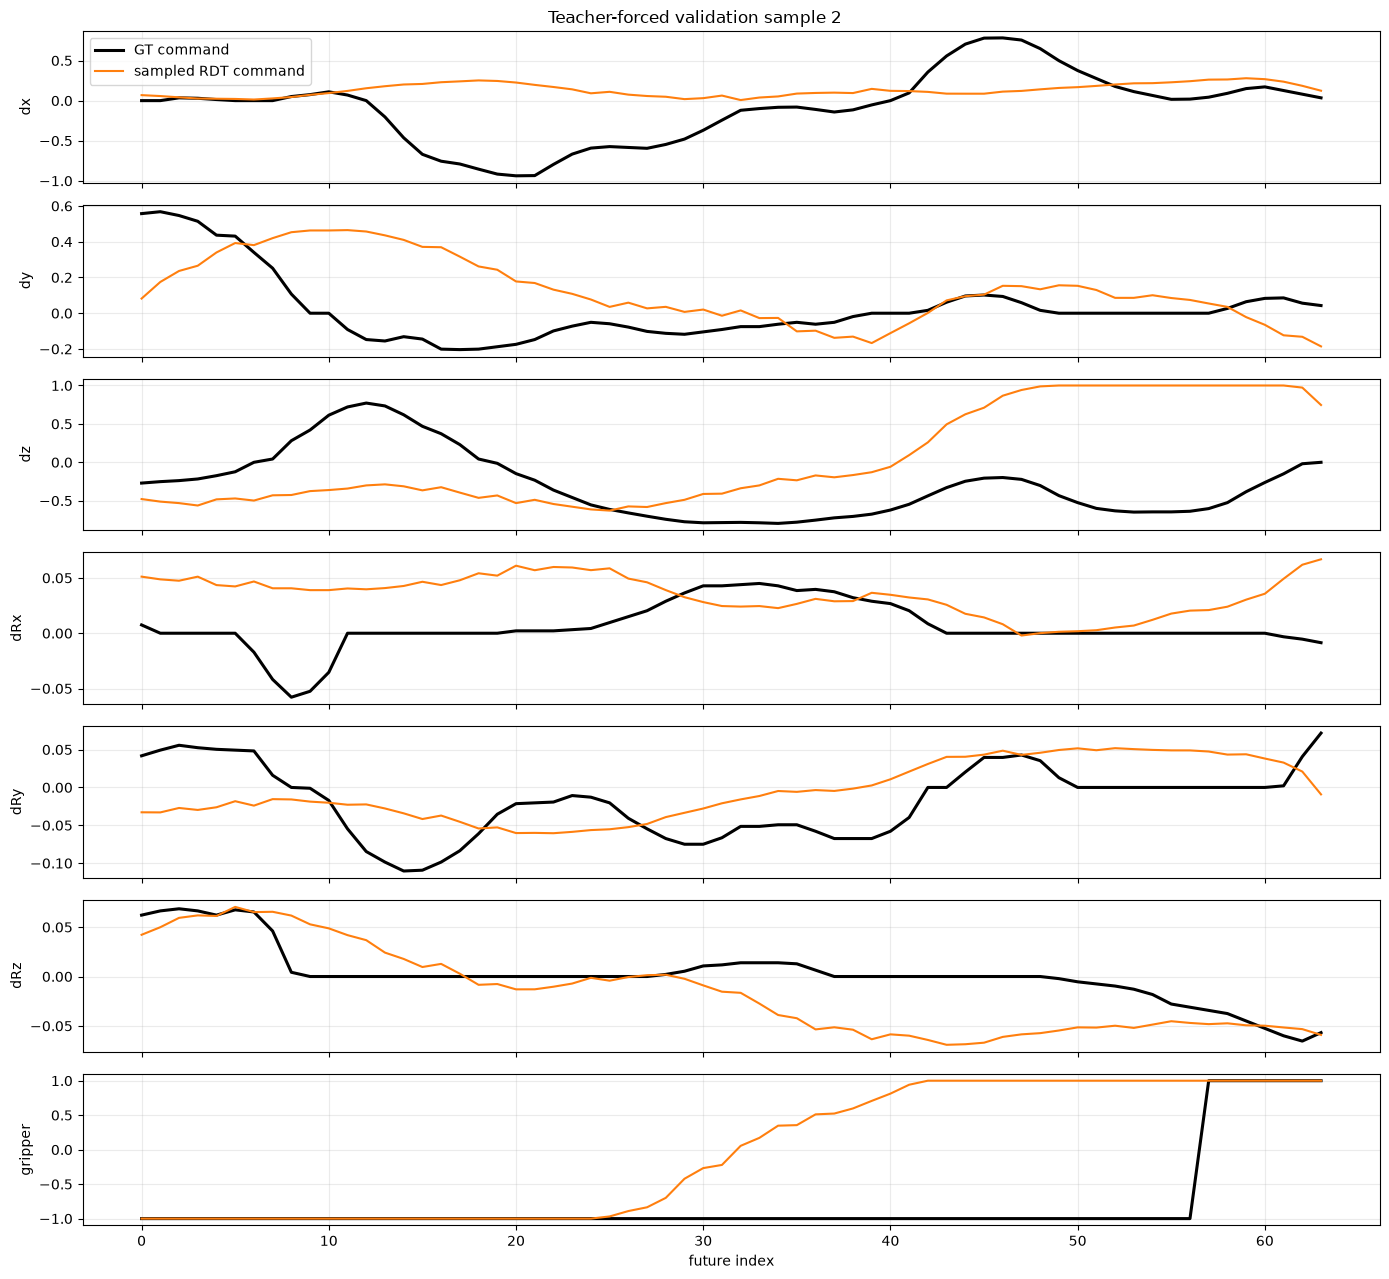

In [7]:
# 3.3 — inspect several complete 64-command predictions
TRACE_INDICES = (0, 1, 2)
command_names = ('dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper')
for sample_index in TRACE_INDICES:
    predicted = rdt_action_to_libero(tensors['prediction_10d'][sample_index].numpy())
    target = rdt_action_to_libero(tensors['target_10d'][sample_index].numpy())
    valid = int(tensors['time_mask'][sample_index].sum())
    fig, axes = plt.subplots(7, 1, figsize=(14, 13), sharex=True)
    for d, ax in enumerate(axes):
        ax.plot(np.arange(valid), target[:valid, d], color='black', linewidth=2.2, label='GT command')
        ax.plot(np.arange(valid), predicted[:valid, d], color='tab:orange', linewidth=1.5, label='sampled RDT command')
        ax.set_ylabel(command_names[d]); ax.grid(alpha=.25)
        if d == 0: ax.legend()
    axes[-1].set_xlabel('future index'); fig.suptitle(f'Teacher-forced validation sample {sample_index}')
    plt.tight_layout(); plt.show()

## 4. Exact-demonstration closed-loop test

One random task and demonstration are selected reproducibly from LIBERO Goal. Both chunk policies start from that demonstration's exact initial MuJoCo state. The rollout saves raw executed commands, observed 11D states, both cameras, summary JSON, and video.

In [8]:
# 4 — select one reproducible random LIBERO Goal task/demo
if str(LIBERO_ROOT) not in sys.path:
    sys.path.insert(0, str(LIBERO_ROOT))
from libero.libero.benchmark import get_benchmark
from thinkflow_rdt.adapters.libero import iter_libero_episodes

benchmark = get_benchmark(SUITE)(0)
candidates = []
for task_id in range(10):
    task = benchmark.get_task(task_id)
    path = DEMO_DATASET_ROOT / SUITE / f'{task.name}_demo.hdf5'
    if path.exists():
        candidates.append({'task_id': task_id, 'task_name': task.name, 'instruction': task.language, 'demo_path': path})
if not candidates:
    raise FileNotFoundError(DEMO_DATASET_ROOT / SUITE)
rng = np.random.default_rng(DEMO_RANDOM_SEED)
selected = dict(candidates[int(rng.integers(len(candidates)))])
with h5py.File(selected['demo_path'], 'r') as handle:
    root = handle['data'] if 'data' in handle else handle
    demo_names = sorted([name for name in root if hasattr(root[name], 'keys') and 'actions' in root[name]], key=lambda x: int(x.rsplit('_', 1)[-1]))
selected['demo_name'] = demo_names[int(rng.integers(len(demo_names)))]
selected = {k: str(v) if isinstance(v, Path) else v for k, v in selected.items()}
display(selected)
(ANALYSIS_ROOT / 'selected_demo.json').write_text(json.dumps(selected, indent=2) + '\n')

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


{'task_id': 4,
 'task_name': 'put_the_bowl_on_top_of_the_cabinet',
 'instruction': 'put the bowl on top of the cabinet',
 'demo_path': '/home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_goal/put_the_bowl_on_top_of_the_cabinet_demo.hdf5',
 'demo_name': 'demo_2'}

272

In [9]:
# 4.1 — run/reuse chunk-1 and chunk-4 exact-demo rollouts
rollout_root = ANALYSIS_ROOT / 'exact_demo'
rollout_root.mkdir(parents=True, exist_ok=True)
jobs = {}
for chunk in ACTION_CHUNKS:
    prefix = rollout_root / f"task{selected['task_id']}_{selected['demo_name']}_chunk{chunk}"
    job = {
        'video': prefix.with_suffix('.mp4'),
        'trace': prefix.with_name(prefix.name + '_actions.jsonl'),
        'observations': prefix.with_name(prefix.name + '_observations.npz'),
        'summary': prefix.with_suffix('.json'),
    }
    job['command'] = [
        sys.executable, str(REPO_ROOT / 'scripts/rollout_libero_rdt.py'),
        '--config', str(CONFIG_PATH), '--benchmark', SUITE, '--task-id', str(selected['task_id']),
        '--checkpoint', str(CHECKPOINT_FOLDER), '--base-artifact', str(BASE_ARTIFACT), '--cache-root', str(CACHE_ROOT),
        '--libero-root', str(LIBERO_ROOT), '--demo-hdf5', selected['demo_path'], '--demo-name', selected['demo_name'],
        '--action-chunk', str(chunk), '--max-steps', str(MAX_STEPS), '--seed', str(SEED), '--qwen-refresh-every', '1',
        '--action-output-mode', 'raw_delta_ortho6d', '--clean-x0-gripper', '--siglip-model-id', siglip_id,
        '--video-resolution', str(VIDEO_RESOLUTION), '--output', str(job['video']),
        '--action-debug-jsonl', str(job['trace']), '--observation-debug-npz', str(job['observations']),
    ]
    jobs[chunk] = job
    print('CHUNK', chunk, '\n', ' '.join(job['command']), '\n')

if RUN_EXACT_DEMO_ROLLOUTS:
    if 'model' in globals(): del model
    gc.collect(); torch.cuda.empty_cache()
    for chunk, job in jobs.items():
        complete = job['trace'].exists() and job['observations'].exists() and job['summary'].exists()
        if complete:
            print(f'Reusing existing chunk-{chunk} trace')
        else:
            print(f'Running chunk {chunk} ...', flush=True)
            subprocess.run(job['command'], cwd=REPO_ROOT, check=True)
else:
    print('Commands printed only; set RUN_EXACT_DEMO_ROLLOUTS=True to execute.')

CHUNK 1 
 /home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python /home/ubuntu/ThinkFlow-RDT-1B/scripts/rollout_libero_rdt.py --config /home/ubuntu/ThinkFlow-RDT-1B/configs/b0_rdt1b_lora.yaml --benchmark libero_goal --task-id 4 --checkpoint /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_from_checkpoint1600/checkpoint-600 --base-artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/checkpoint1600_merged_base_for_libero --cache-root /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d/libero_goal --libero-root /home/ubuntu/LIBERO --demo-hdf5 /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_goal/put_the_bowl_on_top_of_the_cabinet_demo.hdf5 --demo-name demo_2 --action-chunk 1 --max-steps 300 --seed 42 --qwen-refresh-every 1 --action-output-mode raw_delta_ortho6d --clean-x0-gripper --siglip-model-id google/siglip-so400m-patch14-384 --video-resolution 512 --output /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_checkpoint_analysis/libero_goal_from_checkpoint1600__checkpoint-600/exact_d

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:08<00:00, 27.03it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_from_checkpoint1600/checkpoint-600...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=1 success=False elapsed=5.0s
plan=2 simulator_step=2 success=False elapsed=6.5s
plan=3 simulator_step=3 success=False elapsed=8.1s
plan=4 simulator_step=4 success=False elapsed=9.6s
plan=5 simulator_step=5 success=False elapsed=11.1s
plan=6 simulator_step=6 success=False elapsed=12.6s
plan=7 simulator_step=7 success=False elapsed=14.1s
plan=8 simulator_step=8 success=False elapsed=15.7s
plan=9 simulator_step=9 success=False elapsed=17.0s
plan=10 simulator_step=10 success=False elapsed=18.1s
plan=11 simulator_step=11 success=False elapsed=19.2s
plan=12 simulator_step=12 success=False elapsed=20.3s
plan=13 simulator_step=13 success=False elapsed=21.4s
plan=14 simula

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:04<00:00, 49.88it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_from_checkpoint1600/checkpoint-600...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=4 success=False elapsed=4.4s
plan=2 simulator_step=8 success=False elapsed=6.5s
plan=3 simulator_step=12 success=False elapsed=8.7s
plan=4 simulator_step=16 success=False elapsed=11.0s
plan=5 simulator_step=20 success=False elapsed=13.3s
plan=6 simulator_step=24 success=False elapsed=15.5s
plan=7 simulator_step=28 success=False elapsed=17.4s
plan=8 simulator_step=32 success=False elapsed=19.4s
plan=9 simulator_step=36 success=False elapsed=21.2s
plan=10 simulator_step=40 success=False elapsed=23.2s
plan=11 simulator_step=44 success=False elapsed=25.2s
plan=12 simulator_step=48 success=False elapsed=27.2s
plan=13 simulator_step=52 success=False elapsed=29.3s
plan=1

In [10]:
# 4.2 — align executed commands and resulting states to the demonstration
from thinkflow_rdt.adapters.libero import ortho6d_to_rotation_matrix

demo_path = Path(selected['demo_path']); demo_name = selected['demo_name']
episode = next(ep for ep in iter_libero_episodes(demo_path) if ep.episode_id.endswith(f':{demo_name}'))
with h5py.File(demo_path, 'r') as handle:
    root = handle['data'] if 'data' in handle else handle
    gt_commands_all = np.asarray(root[demo_name]['actions'], dtype=np.float32)[:, :7]
gt_states_all = np.asarray(episode.states, dtype=np.float32)

def transitions(values):
    positive = np.asarray(values) >= 0
    return (np.flatnonzero(positive[1:] != positive[:-1]) + 1).tolist()

def first_crossing(values, threshold):
    indices = np.flatnonzero(np.asarray(values) > threshold)
    return int(indices[0]) if len(indices) else None

results = {}; rows = []
for chunk, job in jobs.items():
    if not (job['trace'].exists() and job['observations'].exists()):
        print('Missing rollout outputs for chunk', chunk); continue
    trace_rows = [json.loads(line) for line in job['trace'].read_text().splitlines() if line.strip()]
    predicted_all = np.concatenate([np.asarray(row['executed_libero_actions'], dtype=np.float32) for row in trace_rows])
    realized_all = np.concatenate([np.asarray(row['observed_rdt_states'], dtype=np.float32)[1:] for row in trace_rows])
    n = min(MAX_STEPS, len(predicted_all), len(realized_all), len(gt_commands_all), len(gt_states_all) - 1)
    predicted = predicted_all[:n]; gt_commands = gt_commands_all[:n]
    realized = realized_all[:n]; gt_next = gt_states_all[1:n + 1]
    command_error = predicted - gt_commands
    position_error = np.linalg.norm(realized[:, :3] - gt_next[:, :3], axis=-1)
    R_pred = ortho6d_to_rotation_matrix(realized[:, 3:9]); R_gt = ortho6d_to_rotation_matrix(gt_next[:, 3:9])
    relative = np.swapaxes(R_pred, -1, -2) @ R_gt
    rotation_error = np.arccos(np.clip((np.trace(relative, axis1=-2, axis2=-1) - 1) * .5, -1, 1))
    finger_error = np.linalg.norm(realized[:, 9:11] - gt_next[:, 9:11], axis=-1)
    with np.load(job['observations']) as obs:
        agent_frames = obs['agent_frames'].copy(); wrist_frames = obs['wrist_frames'].copy()
    summary = json.loads(job['summary'].read_text()) if job['summary'].exists() else {}
    results[chunk] = dict(n=n, predicted=predicted, gt_commands=gt_commands, realized=realized, gt_next=gt_next,
        command_error=command_error, position_error=position_error, rotation_error=rotation_error, finger_error=finger_error,
        agent_frames=agent_frames, wrist_frames=wrist_frames, summary=summary)
    rows.append({
        'chunk': chunk, 'steps': n, 'success': summary.get('success'),
        'command_RMSE_7d': float(np.sqrt(np.mean(command_error ** 2))),
        'motion_command_RMSE_6d': float(np.sqrt(np.mean(command_error[:, :6] ** 2))),
        'gripper_sign_accuracy': float(np.mean((predicted[:, 6] >= 0) == (gt_commands[:, 6] >= 0))),
        'position_state_RMSE_m': float(np.sqrt(np.mean(position_error ** 2))),
        'rotation_state_RMSE_rad': float(np.sqrt(np.mean(rotation_error ** 2))),
        'finger_state_RMSE': float(np.sqrt(np.mean(finger_error ** 2))),
        'first_position_error_gt_2cm': first_crossing(position_error, .02),
        'first_rotation_error_gt_0.2rad': first_crossing(rotation_error, .2),
        'GT_gripper_transitions': transitions(gt_commands[:, 6]),
        'predicted_gripper_transitions': transitions(predicted[:, 6]),
    })
summary_df = pd.DataFrame(rows)
display(summary_df)
if rows: (rollout_root / 'closed_loop_metrics.json').write_text(json.dumps(rows, indent=2) + '\n')

,chunk,steps,success,command_RMSE_7d,motion_command_RMSE_6d,gripper_sign_accuracy,position_state_RMSE_m,rotation_state_RMSE_rad,finger_state_RMSE,first_position_error_gt_2cm,first_rotation_error_gt_0.2rad,GT_gripper_transitions,predicted_gripper_transitions
0,1,98,False,0.688825,0.382000,0.387755,0.223334,0.773814,0.039704,7,11,"[32, 92]",[]
1,4,98,False,0.693183,0.390414,0.387755,0.220206,0.890300,0.039693,8,11,"[32, 92]",[]


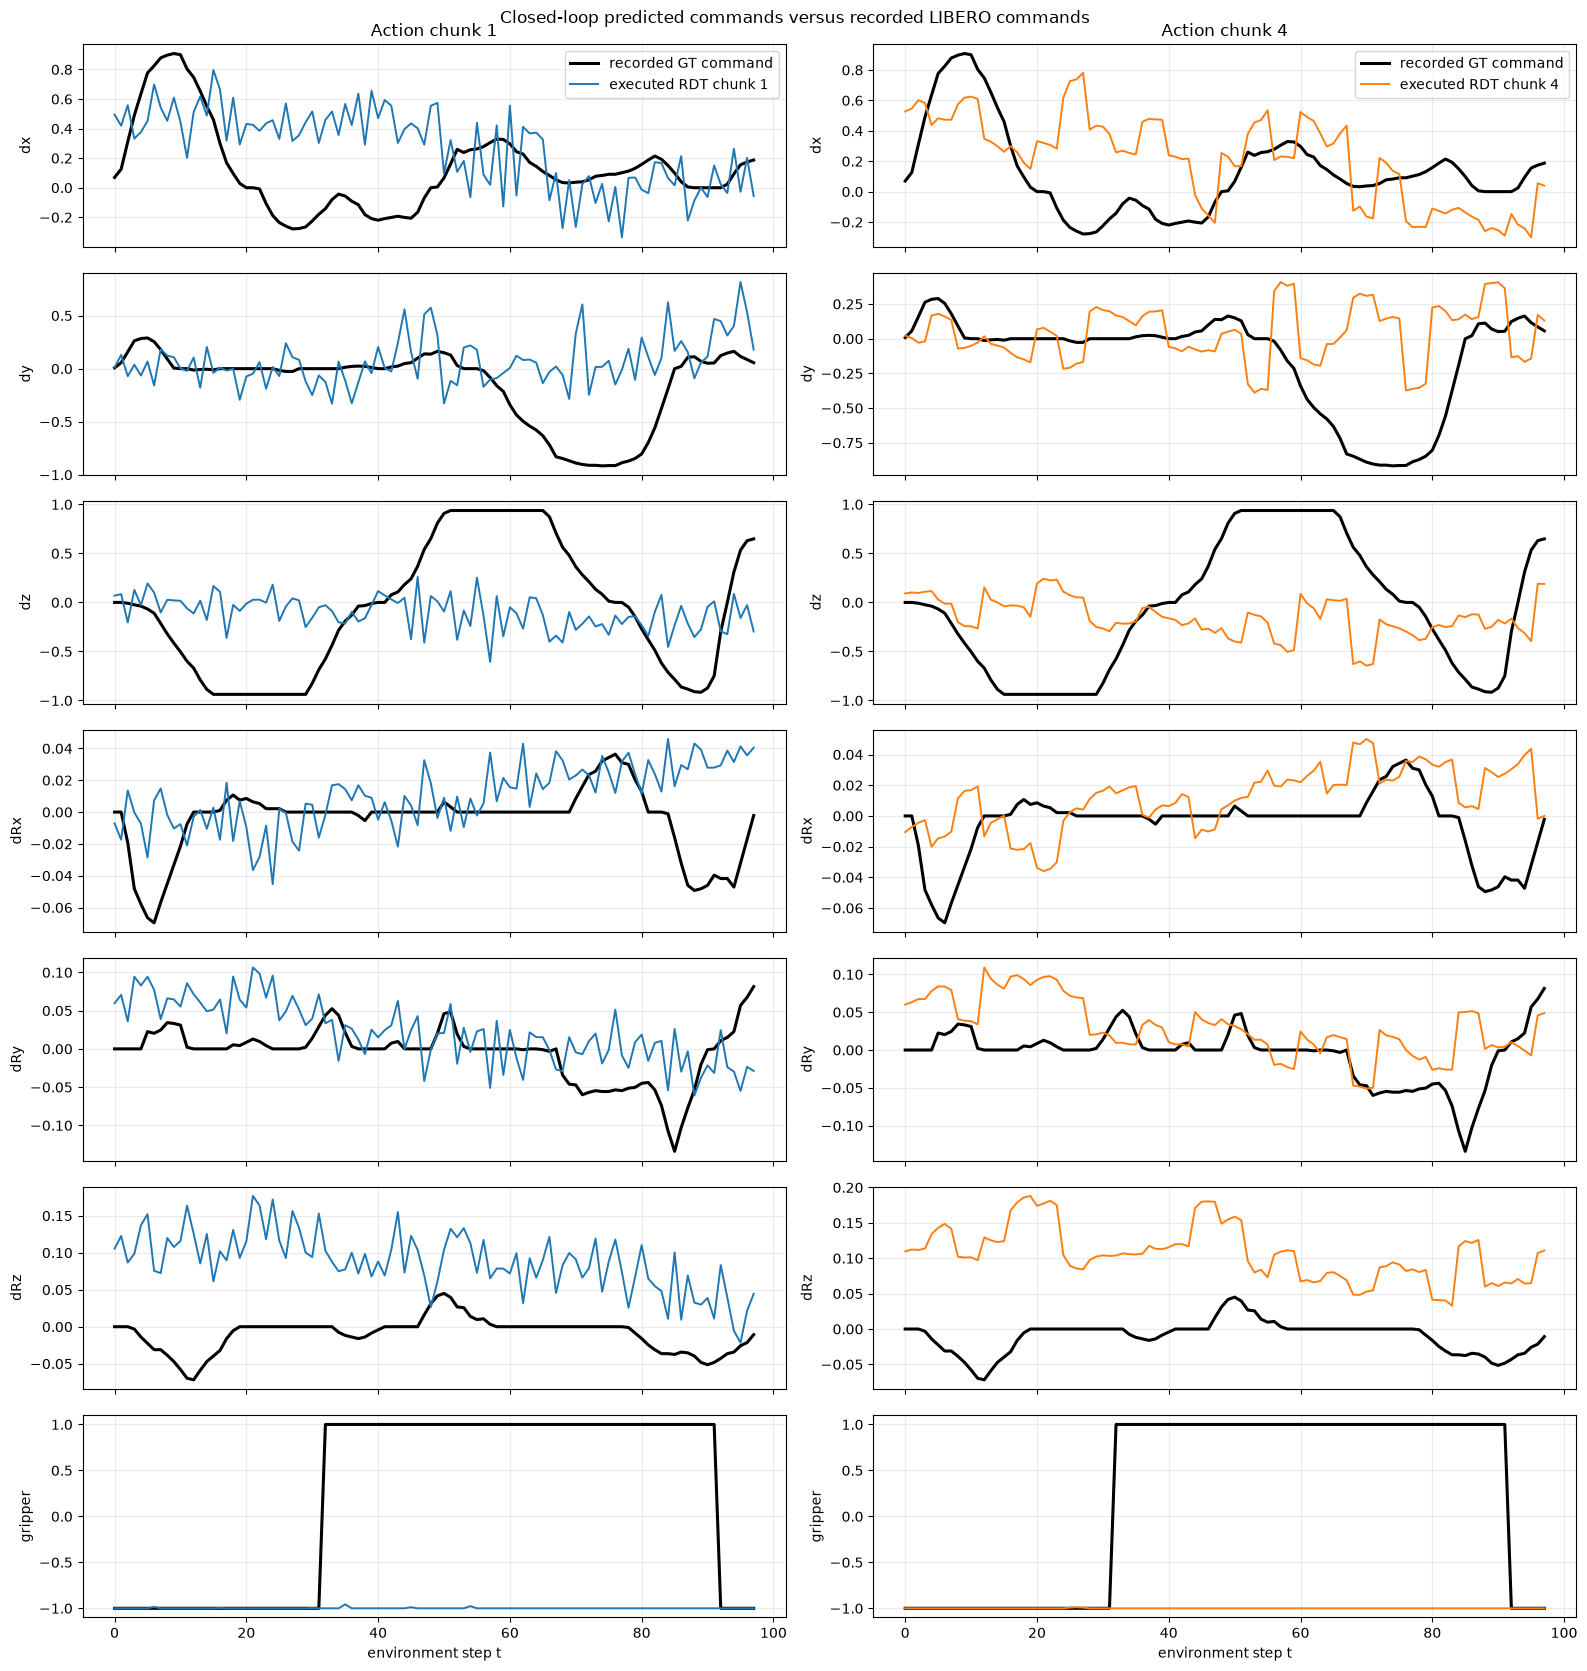

In [11]:
# 4.3 — predicted command versus recorded command across all timesteps
available = [c for c in ACTION_CHUNKS if c in results]
if not available:
    print('Run Section 4.1 first')
else:
    fig, axes = plt.subplots(7, len(available), figsize=(8 * len(available), 17), sharex='col', squeeze=False)
    for column, chunk in enumerate(available):
        r = results[chunk]; steps = np.arange(r['n'])
        for d, name in enumerate(command_names):
            ax = axes[d, column]
            ax.plot(steps, r['gt_commands'][:, d], color='black', linewidth=2.2, label='recorded GT command', zorder=2)
            ax.plot(steps, r['predicted'][:, d], color=('tab:blue' if chunk == 1 else 'tab:orange'), linewidth=1.4, label=f'executed RDT chunk {chunk}', zorder=3)
            ax.set_ylabel(name); ax.grid(alpha=.25)
            if d == 0: ax.set_title(f'Action chunk {chunk}'); ax.legend()
        axes[-1, column].set_xlabel('environment step t')
    fig.suptitle('Closed-loop predicted commands versus recorded LIBERO commands')
    plt.tight_layout(); plt.savefig(rollout_root / 'predicted_vs_gt_commands.png', dpi=160, bbox_inches='tight'); plt.show()

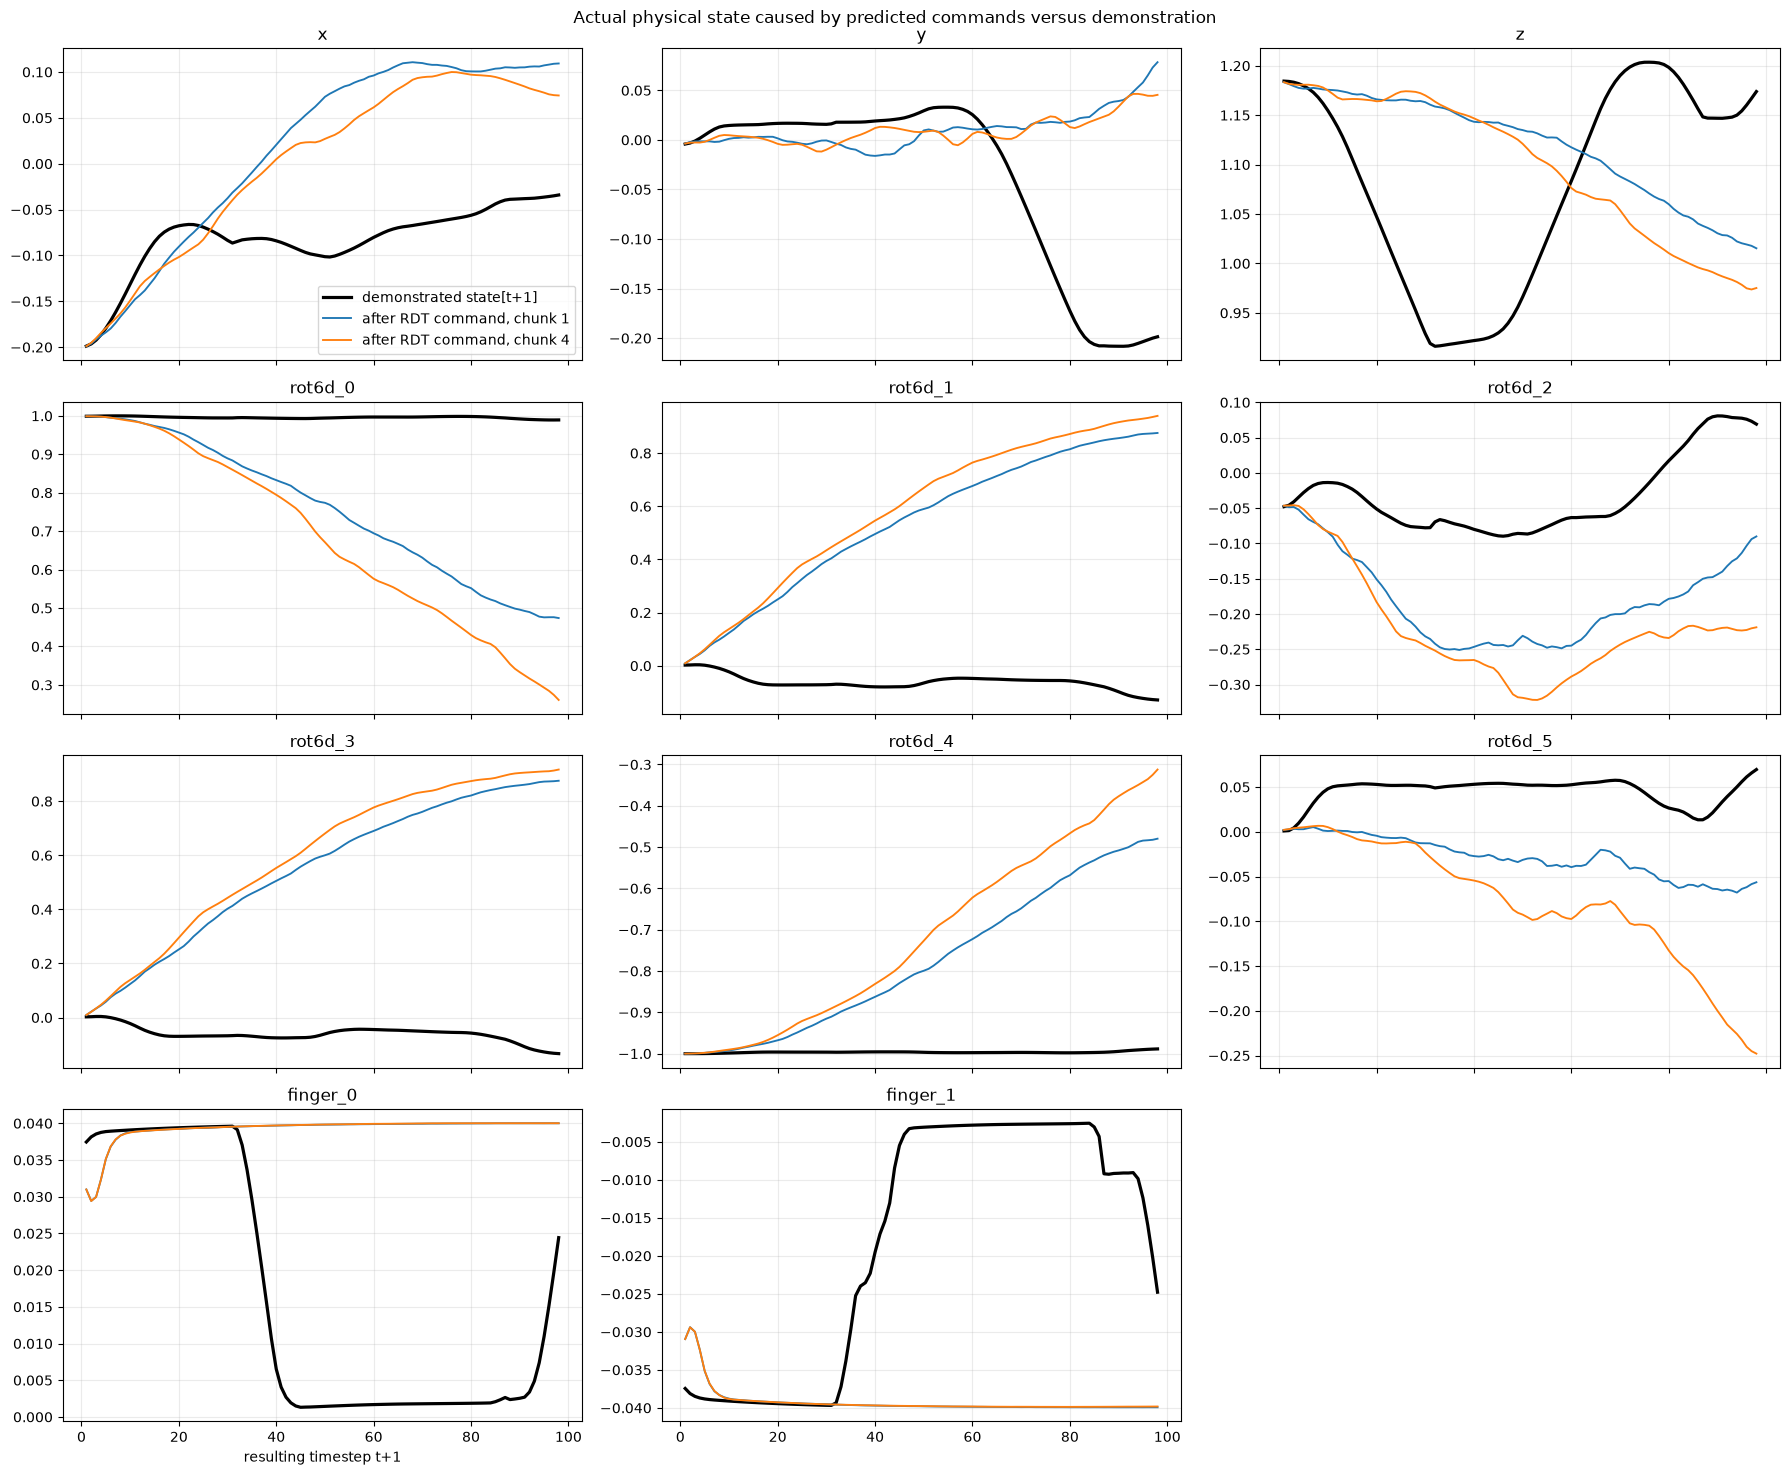

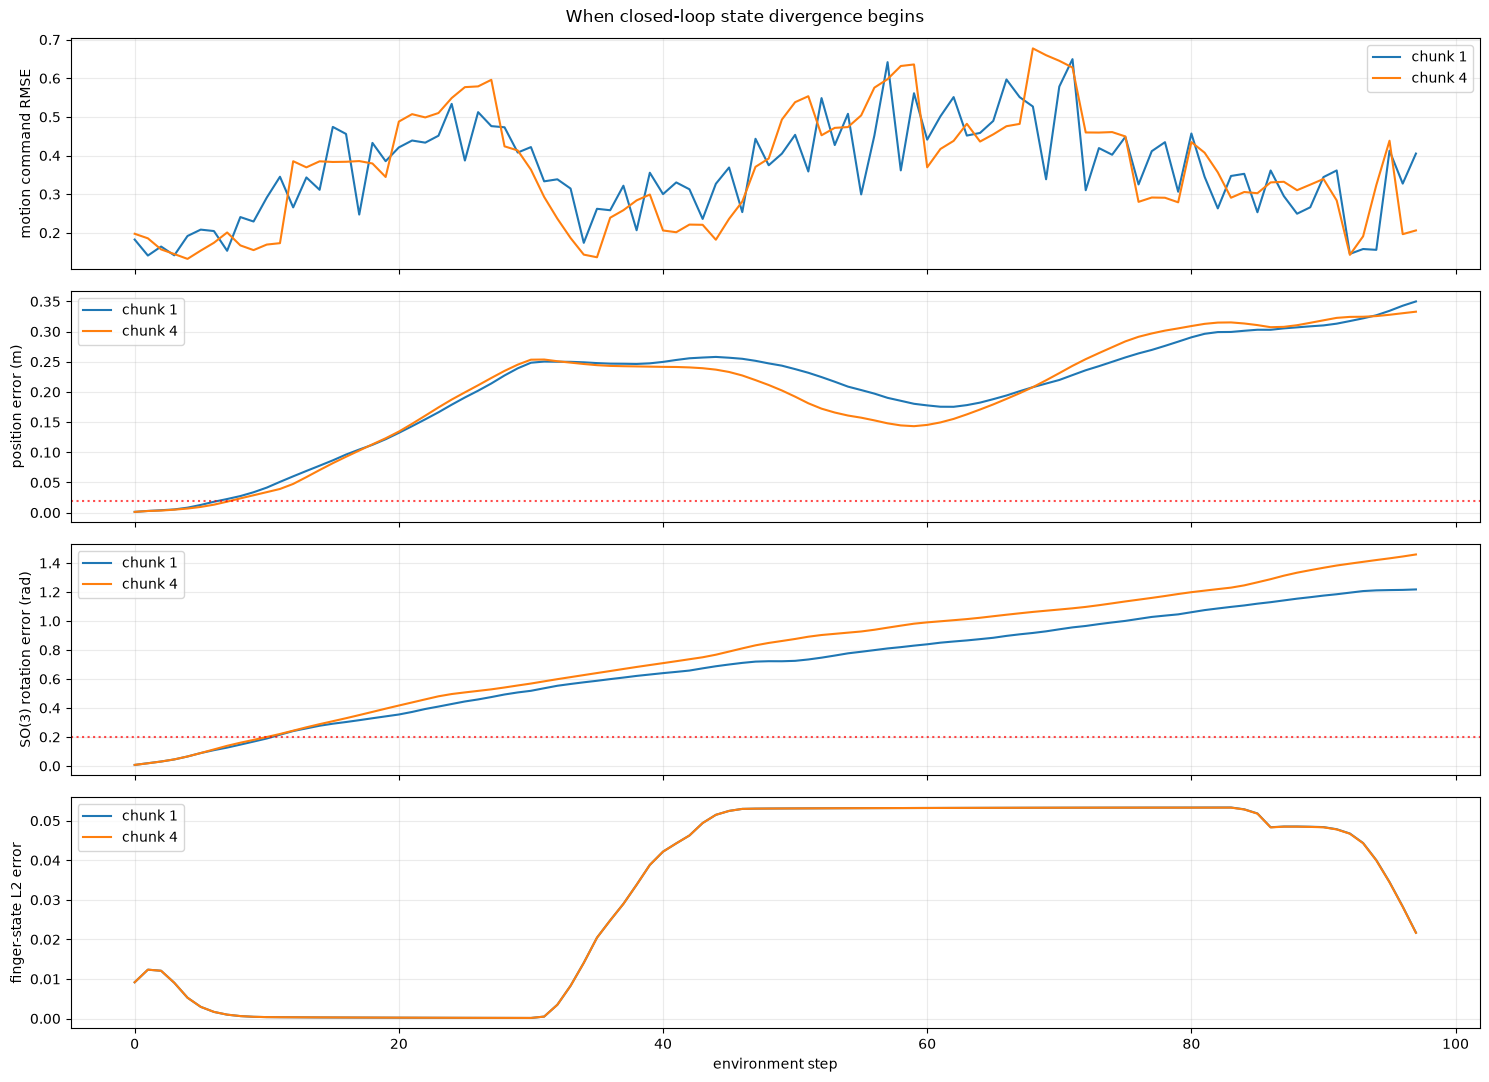

In [12]:
# 4.4 — demonstrated state[t+1] versus state reached after predicted command[t]
state_names = ('x', 'y', 'z', 'rot6d_0', 'rot6d_1', 'rot6d_2', 'rot6d_3', 'rot6d_4', 'rot6d_5', 'finger_0', 'finger_1')
if available:
    fig, axes = plt.subplots(4, 3, figsize=(18, 15), sharex=True)
    for d, ax in enumerate(axes.flat):
        if d >= len(state_names): ax.axis('off'); continue
        max_n = max(results[c]['n'] for c in available)
        ax.plot(np.arange(1, max_n + 1), gt_states_all[1:max_n + 1, d], color='black', linewidth=2.3, label='demonstrated state[t+1]')
        for chunk, color in ((1, 'tab:blue'), (4, 'tab:orange')):
            if chunk in results:
                r = results[chunk]
                ax.plot(np.arange(1, r['n'] + 1), r['realized'][:, d], color=color, linewidth=1.35, label=f'after RDT command, chunk {chunk}')
        ax.set_title(state_names[d]); ax.grid(alpha=.25)
    axes[0, 0].legend(); axes[-1, 0].set_xlabel('resulting timestep t+1')
    fig.suptitle('Actual physical state caused by predicted commands versus demonstration')
    plt.tight_layout(); plt.savefig(rollout_root / 'realized_vs_gt_states.png', dpi=160, bbox_inches='tight'); plt.show()

    fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
    for chunk, color in ((1, 'tab:blue'), (4, 'tab:orange')):
        if chunk not in results: continue
        r = results[chunk]; steps = np.arange(r['n'])
        axes[0].plot(steps, np.sqrt(np.mean(r['command_error'][:, :6] ** 2, axis=1)), color=color, label=f'chunk {chunk}')
        axes[1].plot(steps, r['position_error'], color=color, label=f'chunk {chunk}')
        axes[2].plot(steps, r['rotation_error'], color=color, label=f'chunk {chunk}')
        axes[3].plot(steps, r['finger_error'], color=color, label=f'chunk {chunk}')
    for ax, label in zip(axes, ('motion command RMSE', 'position error (m)', 'SO(3) rotation error (rad)', 'finger-state L2 error')):
        ax.set_ylabel(label); ax.grid(alpha=.25); ax.legend()
    axes[1].axhline(.02, color='red', linestyle=':', alpha=.7); axes[2].axhline(.2, color='red', linestyle=':', alpha=.7)
    axes[-1].set_xlabel('environment step'); fig.suptitle('When closed-loop state divergence begins')
    plt.tight_layout(); plt.savefig(rollout_root / 'closed_loop_errors.png', dpi=160, bbox_inches='tight'); plt.show()

chunk 1: GT close starts 32, GT release starts 92, predicted transitions []
chunk 4: GT close starts 32, GT release starts 92, predicted transitions []


,chunk,phase,commands,motion_command_RMSE_6d,gripper_accuracy,position_error_mean_m,rotation_error_mean_rad
0,1,approach_open,32,0.355270,1.0,0.103259,0.279888
1,1,close_hold,60,0.403110,0.0,0.244059,0.861574
2,1,release_open,6,0.292045,1.0,0.332224,1.209760
3,4,approach_open,32,0.369855,1.0,0.103154,0.309768
4,4,close_hold,60,0.410802,0.0,0.235849,0.987840
5,4,release_open,6,0.269145,1.0,0.327592,1.426721


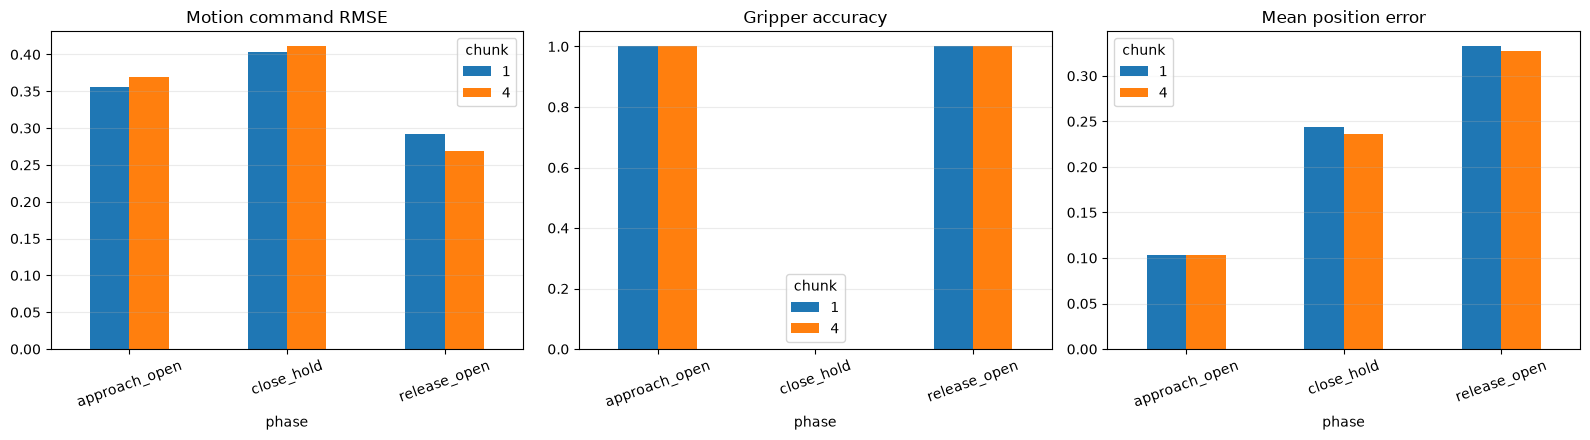

In [13]:
# 4.5 — command/state errors split into approach-open, close/hold, and release-open
# Raw LIBERO convention used by this project: command >= 0 closes; command < 0 opens.
def phase_masks(gt_gripper):
    closed = np.asarray(gt_gripper) >= 0
    close_indices = np.flatnonzero(closed)
    first_close = int(close_indices[0]) if len(close_indices) else len(closed)
    release_indices = np.flatnonzero((~closed) & (np.arange(len(closed)) > first_close))
    first_release = int(release_indices[0]) if len(release_indices) else len(closed)
    index = np.arange(len(closed))
    return {
        'approach_open': index < first_close,
        'close_hold': (index >= first_close) & (index < first_release),
        'release_open': index >= first_release,
    }, first_close, first_release

phase_rows = []
for chunk in available:
    r = results[chunk]; masks, first_close, first_release = phase_masks(r['gt_commands'][:, 6])
    for phase_name, mask in masks.items():
        if not mask.any(): continue
        phase_rows.append({
            'chunk': chunk, 'phase': phase_name, 'commands': int(mask.sum()),
            'motion_command_RMSE_6d': float(np.sqrt(np.mean(r['command_error'][mask, :6] ** 2))),
            'gripper_accuracy': float(np.mean((r['predicted'][mask, 6] >= 0) == (r['gt_commands'][mask, 6] >= 0))),
            'position_error_mean_m': float(r['position_error'][mask].mean()),
            'rotation_error_mean_rad': float(r['rotation_error'][mask].mean()),
        })
    print(f'chunk {chunk}: GT close starts {first_close}, GT release starts {first_release}, predicted transitions {transitions(r["predicted"][:, 6])}')
phase_df = pd.DataFrame(phase_rows)
display(phase_df)
if not phase_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, metric, title in zip(axes, ('motion_command_RMSE_6d', 'gripper_accuracy', 'position_error_mean_m'), ('Motion command RMSE', 'Gripper accuracy', 'Mean position error')):
        phase_df.pivot(index='phase', columns='chunk', values=metric).reindex(['approach_open', 'close_hold', 'release_open']).plot.bar(ax=ax, rot=20)
        ax.set_title(title); ax.grid(axis='y', alpha=.25)
    plt.tight_layout(); plt.savefig(rollout_root / 'phase_errors.png', dpi=160, bbox_inches='tight'); plt.show()

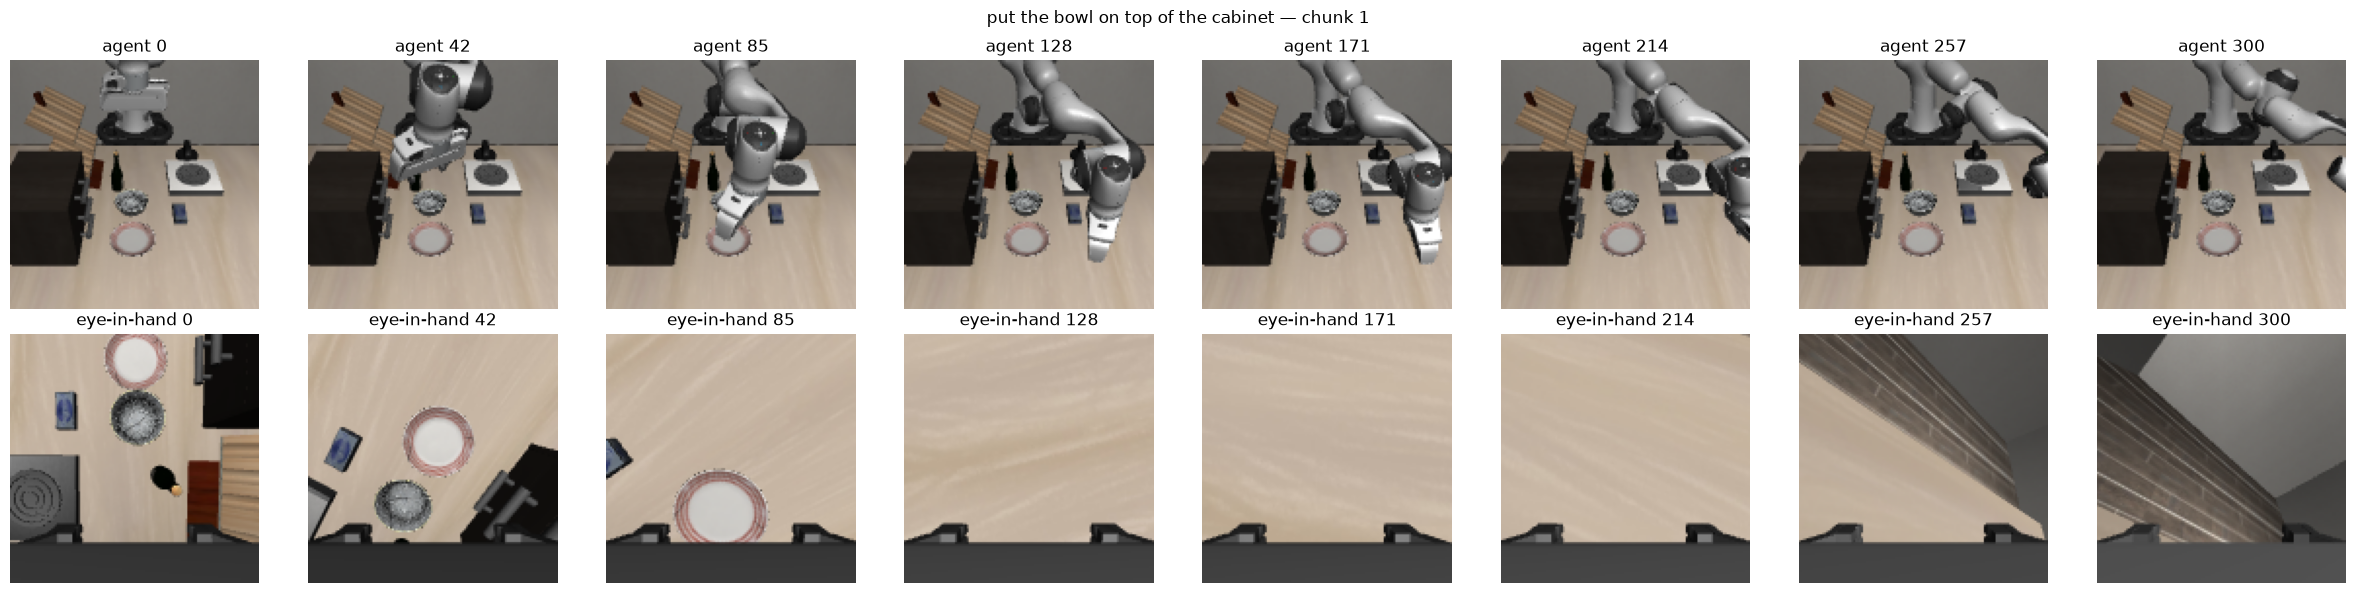

/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_checkpoint_analysis/libero_goal_from_checkpoint1600__checkpoint-600/exact_demo/task4_demo_2_chunk1.mp4


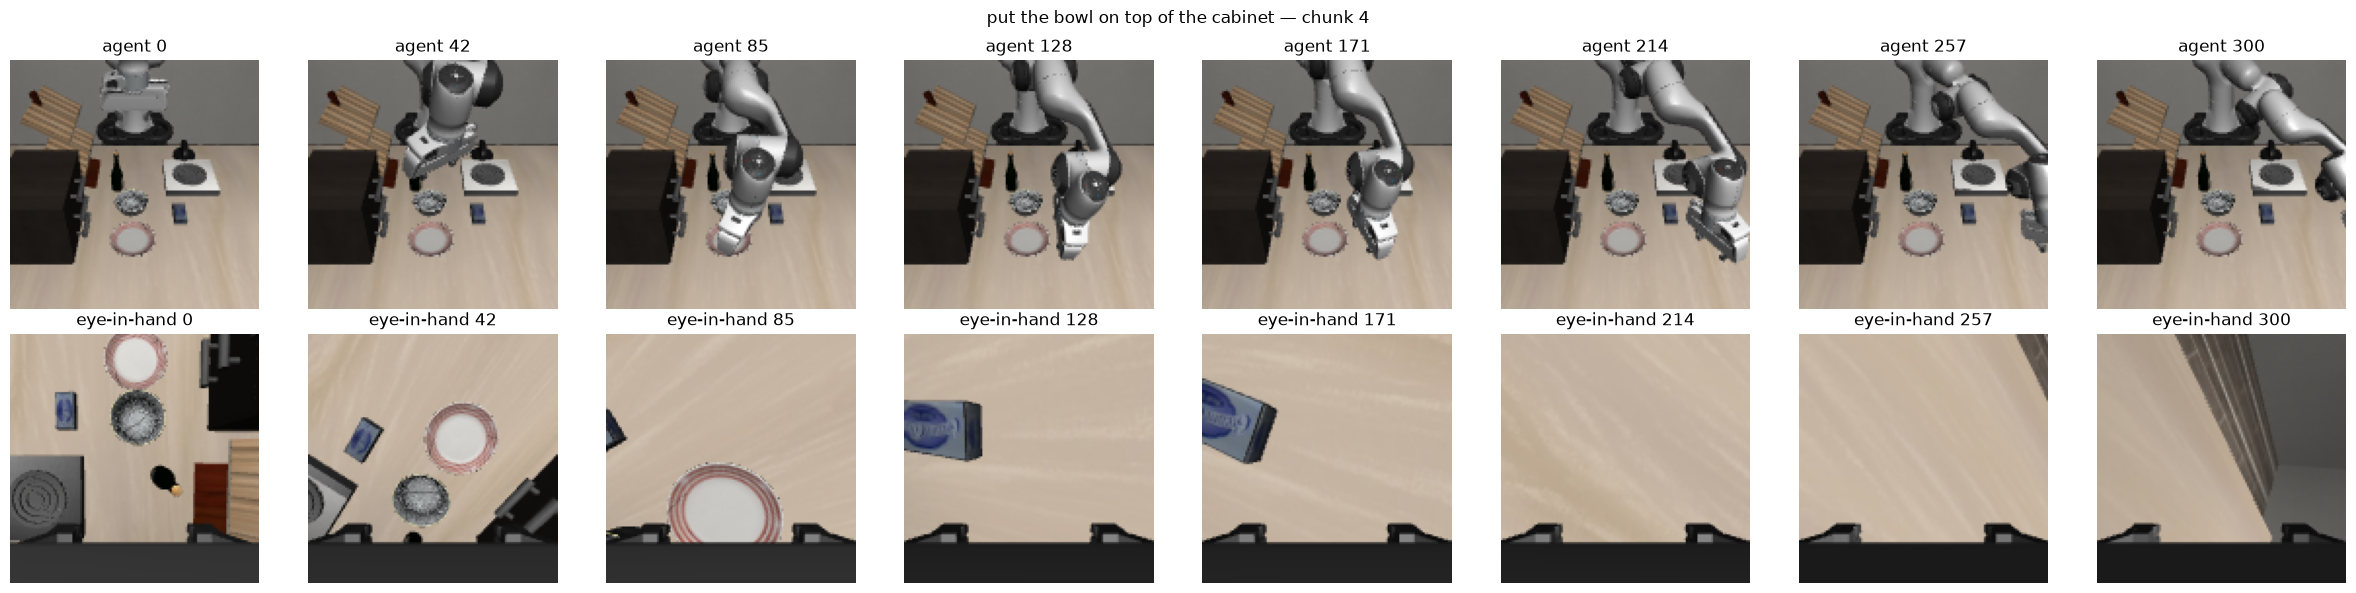

/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_goal_checkpoint_analysis/libero_goal_from_checkpoint1600__checkpoint-600/exact_demo/task4_demo_2_chunk4.mp4


In [14]:
# 4.6 — synchronized agent/eye-in-hand frames and saved videos
for chunk in available:
    r = results[chunk]; frame_count = min(len(r['agent_frames']), len(r['wrist_frames']))
    frame_steps = np.unique(np.linspace(0, frame_count - 1, min(8, frame_count), dtype=int))
    fig, axes = plt.subplots(2, len(frame_steps), figsize=(3 * len(frame_steps), 6), squeeze=False)
    for column, step in enumerate(frame_steps):
        axes[0, column].imshow(r['agent_frames'][step]); axes[0, column].set_title(f'agent {step}'); axes[0, column].axis('off')
        axes[1, column].imshow(r['wrist_frames'][step]); axes[1, column].set_title(f'eye-in-hand {step}'); axes[1, column].axis('off')
    fig.suptitle(f"{selected['instruction']} — chunk {chunk}")
    plt.tight_layout(); plt.savefig(rollout_root / f'camera_frames_chunk{chunk}.png', dpi=160, bbox_inches='tight'); plt.show()
    if jobs[chunk]['video'].exists():
        print(jobs[chunk]['video']); display(Video(str(jobs[chunk]['video']), embed=False, width=720))

## 5. Automated interpretation

The following cell identifies whether the main failure is already visible under teacher forcing, begins at the grasp/release transition, or primarily appears through closed-loop compounding. Thresholds are diagnostic—not LIBERO success criteria.

In [ ]:
# 5 — concise evidence-based interpretation
print('CHECKPOINT', metadata.get('global_step'), 'SUITE', SUITE)
for h in ('1', '4', '8', '64'):
    value = metrics['horizon_rmse'].get(h)
    if value: print(f"teacher-forced h{h}: motion RMSE={value['motion_rmse_6d']:.4f}, gripper RMSE={value['gripper_rmse']:.4f}")
print('teacher-forced gripper accuracy/F1:', metrics['gripper']['accuracy'], metrics['gripper']['f1'])
for d in ('dRx', 'dRy', 'dRz'):
    print(d, 'correlation=', metrics['per_dimension_correlation'][d], 'sign=', metrics['per_dimension_sign_agreement'][d])

if summary_df.empty:
    print('No closed-loop traces yet.')
else:
    display(summary_df)
    for _, row in summary_df.iterrows():
        chunk = int(row['chunk'])
        if row['first_position_error_gt_2cm'] is None:
            print(f'chunk {chunk}: position stayed within 2 cm for the compared trajectory')
        else:
            print(f"chunk {chunk}: position first exceeded 2 cm at step {row['first_position_error_gt_2cm']}")
    if 1 in results and 4 in results:
        c1 = summary_df.set_index('chunk').loc[1]; c4 = summary_df.set_index('chunk').loc[4]
        ratio = c4.motion_command_RMSE_6d / max(c1.motion_command_RMSE_6d, 1e-12)
        print(f'chunk-4/chunk-1 closed-loop motion RMSE ratio: {ratio:.3f}')
        if ratio > 1.25:
            print('Finding: later-horizon execution materially worsens the trajectory; prefer chunk 1 while debugging.')
        else:
            print('Finding: chunk size is not the dominant difference on this demonstration.')
    if not phase_df.empty:
        worst = phase_df.sort_values('position_error_mean_m', ascending=False).iloc[0]
        print(f"Largest phase position error: chunk {int(worst.chunk)} {worst.phase} ({worst.position_error_mean_m:.4f} m mean)")
print('Inspect plots and video around the first divergence; low teacher-forced error cannot prove closed-loop recovery from off-demo states.')